# Mean-field applications: TDA, RPA and QRPA

Companion notebook to Chapter 7 of *Quantum mechanics for many-particle
systems*.  Every number quoted in the chapter is produced here; the code is
the same as in `BookManybody/BookMaterial/Programs/rpa.py`.

The model has $L$ doubly degenerate, equally spaced levels $p=1,\dots,L$ with
spin $\sigma=\pm$, holding $N$ fermions:

$$\hat H_0 = \xi\sum_{p\sigma}(p-1)\,a^\dagger_{p\sigma}a_{p\sigma},$$
$$\hat V_{\rm pair} = -\frac{g}{2}\sum_{pq}
   a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{q+},\qquad
  \hat V_{\rm ph} = -\frac{f}{2}\sum_{pqr}
   \left(a^\dagger_{p+}a^\dagger_{p-}a_{q-}a_{r+} + {\rm h.c.}\right).$$

At $f=0$ this is exactly the pairing model of Chapter 4.  The particle-hole
term breaks pairs, which is what the pairing term cannot do.

Contents:

1. The model and its exact spectrum
2. The Hartree-Fock reference
3. Validating the $A$ and $B$ matrices
4. Tamm-Dancoff and RPA
5. RPA and the stability of the mean field
6. BCS
7. Quasiparticle RPA, the spurious mode and the mode content
8. Everything against everything

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.join("..", "BookManybody", "BookMaterial", "Programs"))
import rpa

np.set_printoptions(precision=6, suppress=True, linewidth=120)

## 1. The model and its exact spectrum

Exact diagonalisation is Chapter 5 applied without modification: determinants
are bit strings, the Hamiltonian is built by applying each term to every
basis state, and the lowest eigenvalues follow from Chapter 1's algorithms.
Restricting to the balanced $S_z=0$ sector cuts the dimension from
$\binom{8}{4}=70$ to 36.

In [2]:
rpa.demo_model()

1. The model, and its exact spectrum
L = 4 levels, N = 4 particles
full space          C(8,4) = 70
balanced S_z = 0 sector     = 36

At f = 0 the model is the pairing model of chapter 4.  The exact
energies must reproduce Table 4.2:
      g        E_ref    E_0 (exact)      chapter 4
  -1.00     3.000000     2.77987014     2.77987014
  -0.50     2.500000     2.43688426     2.43688426
   0.00     2.000000     2.00000000     2.00000000
   0.50     1.500000     1.41677428     1.41677428
   1.00     1.000000     0.63554847     0.63554847

Switching on the particle-hole term, g = 0.5 and f = 0.05 g:
   E_0 = 1.347133
   E_1 = 2.710867
   E_2 = 2.711098
   E_3 = 3.413340
   E_4 = 3.704452
   E_5 = 3.704504

The particle-hole term breaks pairs, so the seniority of chapter 5
is no longer conserved and the whole S_z = 0 space is active.


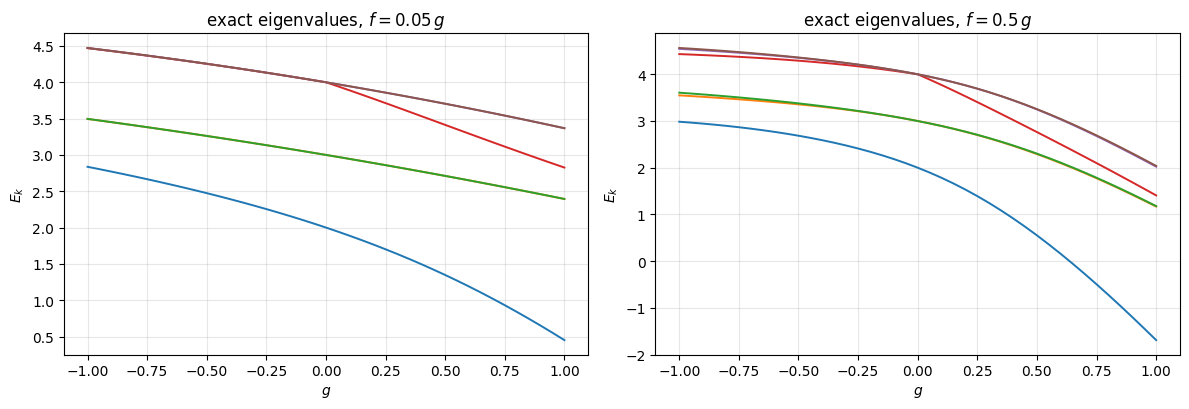

In [3]:
gs = np.linspace(-1.0, 1.0, 41)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for alpha, panel in ((0.05, 0), (0.5, 1)):
    data = np.array([rpa.PairingPH(levels=4, particles=4,
                                   g=g, f=alpha * g).spectrum(6) for g in gs])
    for m in range(data.shape[1]):
        ax[panel].plot(gs, data[:, m], lw=1.4)
    ax[panel].set_xlabel("$g$"); ax[panel].set_ylabel("$E_k$")
    ax[panel].set_title(rf"exact eigenvalues, $f = {alpha}\,g$")
    ax[panel].grid(alpha=0.3)
fig.tight_layout(); plt.show()

The weak-$f$ panel shows the near-degenerate pairs of the pairing model,
split only slightly.  At $f = 0.5\,g$ the pair-breaking term reorganises the
low-lying structure and levels cross.

## 2. The Hartree-Fock reference

Both approximations are built on a stationary mean field.  With pure pairing
the filled Fermi sea is already the solution, as Chapter 6 found; the
particle-hole term makes the iteration non-trivial.

In [4]:
rpa.demo_hartree_fock()

2. The Hartree-Fock reference
     g       f        E_HF  iterations   single-particle energies
  0.70   0.000     1.30000           2   -0.350  -0.350   0.650   0.650 ...
  0.70   0.050     1.19709          20   -0.404  -0.404   0.600   0.600 ...
  1.00   0.500    -0.26976          40   -1.505  -1.505   0.119   0.119 ...

With pure pairing the filled Fermi sea is already the Hartree-Fock
solution -- the interaction cannot connect it to a 1p-1h state, as
chapter 6 found.  The occupied levels are shifted down by g/2 and
the empty ones are untouched.  The particle-hole term does connect
them, so the mean field must rotate the orbitals to restore
Brillouin's theorem, and the iteration becomes non-trivial.


## 3. Validating the $A$ and $B$ matrices

Everything is computed as literal double commutators

$$A_{KL} = \langle 0|[\hat O_K^\dagger,[\hat H,\hat O_L]]|0\rangle,\qquad
  B_{KL} = -\langle 0|[\hat O_K^\dagger,[\hat H,\hat O_L^\dagger]]|0\rangle,$$

so it is worth checking against the textbook expressions.  The important
identity is the first one below: the Tamm-Dancoff matrix **is** the
Hamiltonian restricted to the $1p$-$1h$ block, measured from the reference.
TDA is CIS.

In [5]:
rpa.demo_validation()

3. Validating the A and B matrices


Everything is computed from double commutators, so it is worth
checking against the textbook expressions and against a direct
matrix construction.

  E_HF from <HF|H|HF>                    = 1.19708590
  E_HF from the self-consistent field    = 1.19708590
  max |<HF|H|1p-1h>|  (Brillouin)        = 3.99e-13
  max |A - (H_1p1h - E_HF)|              = 3.11e-15


  max |A - [(e_m-e_i)dd + vbar_mjin]|    = 5.28e-14
  max |B - vbar_mnij|                    = 3.33e-16

The first identity is the important one: the Tamm-Dancoff matrix
is literally the Hamiltonian restricted to the 1p-1h block,
measured from the reference.  TDA is the configuration-interaction
truncation of chapter 5 applied to excited states, no more.


## 4. Tamm-Dancoff and RPA

$$\hat Q^\dagger_\nu = \sum_{mi}\left(X^\nu_{mi}a^\dagger_m a_i
  - Y^\nu_{mi}a^\dagger_i a_m\right),\qquad
\begin{pmatrix}A & B\\ -B^* & -A^*\end{pmatrix}
\begin{pmatrix}X^\nu\\ Y^\nu\end{pmatrix}
= \omega_\nu\begin{pmatrix}X^\nu\\ Y^\nu\end{pmatrix}.$$

Setting $B=0$ recovers TDA.  The RPA correlation energy is

$$E^{\rm RPA}_{\rm corr} = \tfrac12\left(\sum_\nu\omega_\nu - {\rm Tr}\,A\right).$$

In [6]:
rpa.demo_tda_rpa()

4. Tamm-Dancoff and RPA in the particle-hole channel
     g       f       E_HF    E_HF+E_c    E_exact    TDA w1    RPA w1   exact w1
  0.50   0.025    1.44927     1.29898    1.34713    1.2748    1.2448     1.3637


  0.70   0.050    1.19709     0.89759    0.96976    1.3992    1.3412     1.5972


  1.00   0.050    0.89709     0.36862    0.45058    1.5492    1.4488     1.9425
  1.00   0.500   -0.26976    -1.73461   -1.69174    1.8111    1.6445     2.8596

RPA lowers the energy below Hartree-Fock and overshoots the exact
ground state: the quasiboson approximation, which replaces the
exact commutator of two particle-hole operators by its expectation
value in the reference, double counts the correlations.  The RPA
root always lies below the TDA one, for the same reason.



dimension of the particle-hole space: 16 = (2L - N) x N = 4 x 4
Tr A = 38.423313, sum of RPA roots = 37.824314, E_corr = -0.299500

For pure pairing the whole particle-hole problem collapses to a
two-by-two structure and both answers are closed forms,
   TDA:  w = xi + g/2,          RPA:  w = sqrt(xi^2 + g xi),
the second being sqrt(A^2 - B^2) with A = xi + g/2 and B = g/2.
     g          TDA     xi + g/2          RPA    sqrt(1+g)


  0.50   1.25000000   1.25000000   1.22474487   1.22474487
  1.00   1.50000000   1.50000000   1.41421356   1.41421356
  2.00   2.00000000   2.00000000   1.73205081   1.73205081


  3.00   2.50000000   2.50000000   2.00000000   2.00000000


  5.00   3.50000000   3.50000000   2.44948974   2.44948974


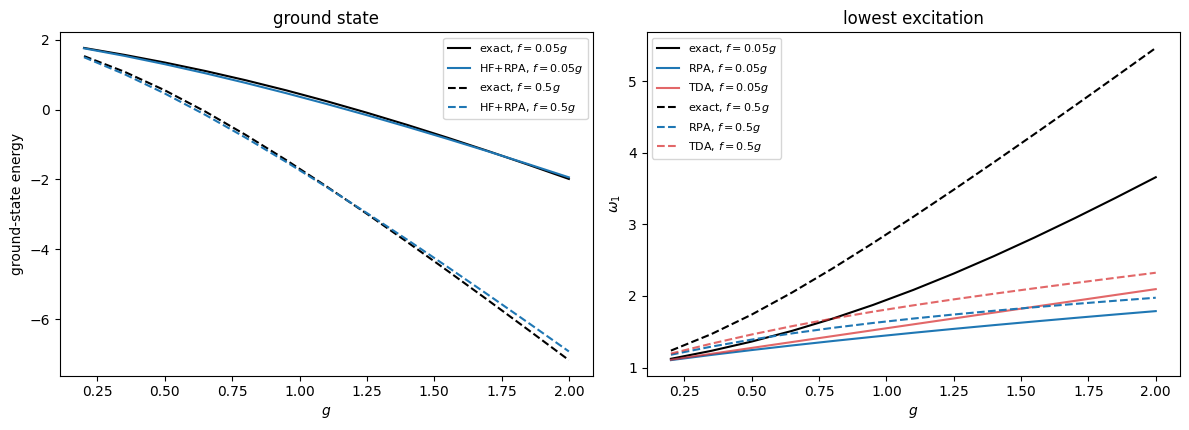

In [7]:
fock = rpa.FockSpace(4)
gs = np.linspace(0.2, 2.0, 13)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.4))
for frac, style in ((0.05, "-"), (0.5, "--")):
    e0, e_rpa, w_ex, w_tda, w_rpa = [], [], [], [], []
    for g in gs:
        f = frac * g
        ex = rpa.PairingPH(levels=4, particles=4, g=g, f=f).spectrum(2)
        r = rpa.tda_rpa(fock, 4, g, f)
        e0.append(ex[0]); e_rpa.append(r["hf"] + r["ecorr"])
        w_ex.append(ex[1] - ex[0]); w_tda.append(r["tda"][0])
        w_rpa.append(r["rpa"][0])
    lab = f"$f = {frac}g$"
    ax[0].plot(gs, e0, "k" + style, label=f"exact, {lab}")
    ax[0].plot(gs, e_rpa, "C0" + style, label=f"HF+RPA, {lab}")
    ax[1].plot(gs, w_ex, "k" + style, label=f"exact, {lab}")
    ax[1].plot(gs, w_rpa, "C0" + style, label=f"RPA, {lab}")
    ax[1].plot(gs, w_tda, "C3" + style, alpha=0.7, label=f"TDA, {lab}")
ax[0].set_xlabel("$g$"); ax[0].set_ylabel("ground-state energy")
ax[0].set_title("ground state"); ax[0].legend(fontsize=8)
ax[1].set_xlabel("$g$"); ax[1].set_ylabel(r"$\omega_1$")
ax[1].set_title("lowest excitation"); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

RPA lowers the energy below Hartree-Fock and overshoots the exact ground
state -- the quasiboson approximation over-counts the correlations.  Both TDA
and RPA put the lowest excitation well below the exact one, and the gap widens
with the pairing strength: the particle-hole phonon knows nothing about
pairing correlations.

### A closed form

For pure pairing the whole particle-hole problem collapses and

$$\omega^{\rm TDA} = \xi + \frac{g}{2},\qquad
  \omega^{\rm RPA} = \sqrt{\xi^2 + g\xi}
   = \sqrt{\left(\xi+\tfrac{g}{2}\right)^2 - \left(\tfrac{g}{2}\right)^2},$$

the classic $\sqrt{A^2-B^2}$ of a two-level RPA problem.  Note that the root
is real for every $g > -\xi$: the particle-hole channel of the pairing model
never goes unstable.

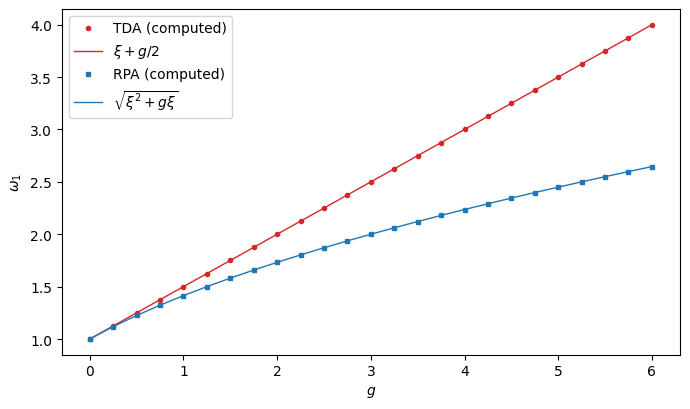

In [8]:
gs = np.linspace(0.0, 6.0, 25)
solved = [rpa.tda_rpa(fock, 4, g, 0.0) for g in gs]
tda = [s["tda"][0] for s in solved]
rr  = [s["rpa"][0] for s in solved]

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(gs, tda, "C3o", ms=3, label="TDA (computed)")
ax.plot(gs, 1.0 + 0.5 * gs, "C3-", lw=1, label=r"$\xi + g/2$")
ax.plot(gs, rr, "C0s", ms=3, label="RPA (computed)")
ax.plot(gs, np.sqrt(1.0 + gs), "C0-", lw=1, label=r"$\sqrt{\xi^2+g\xi}$")
ax.set_xlabel("$g$"); ax.set_ylabel(r"$\omega_1$")
ax.legend(); fig.tight_layout(); plt.show()

## 5. RPA and the stability of the mean field

Chapter 6's stability matrix and the RPA matrix are built from the *same*
blocks, differently arranged:

$$\hat M_{\rm stab} = \begin{pmatrix}A & B\\ B^* & A^*\end{pmatrix}
  \ ({\rm Hermitian}),\qquad
  \hat M_{\rm RPA} = \begin{pmatrix}A & B\\ -B^* & -A^*\end{pmatrix}
  = \eta\,\hat M_{\rm stab}.$$

The RPA frequencies are real exactly when $\hat M_{\rm stab}\ge 0$, that is,
exactly when the mean field is a local minimum.  The Lipkin model shows the
collective root going soft at $\chi=1$ and turning imaginary beyond.

In [9]:
rpa.demo_stability()

5. RPA and the stability of the mean field
Chapter 6 built the stability matrix
   M_stab = [[Delta+A, B], [B*, Delta+A*]]   (Hermitian)
and showed that the Hartree-Fock solution is a minimum only if it
is positive semi-definite.  RPA diagonalises the *same* blocks in
the non-Hermitian arrangement
   M_RPA  = [[A, B], [-B*, -A*]]
whose eigenvalues are +/- w.  The two statements are equivalent:
the RPA frequencies are real precisely when M_stab >= 0.

The Lipkin model of chapters 4 and 6 shows this directly.
   chi   min eig M_stab   #imaginary   lowest real root
  0.25       0.75000000            0           0.968246
  0.50       0.50000000            0           0.866025
  0.90       0.10000000            0           0.435890
  1.00       0.00000000            0           0.000000
  1.50      -0.50000000            2           0.866025
  2.00      -1.00000000            2           0.745356

The collective root goes soft exactly at chi = 1, where the
stability matrix acquires a zero e

  4.00    2.00       1.11547342            0
The particle-hole channel is simply not where this model becomes
collective.  Its instability is in the pairing channel, which is
what BCS and QRPA are for.


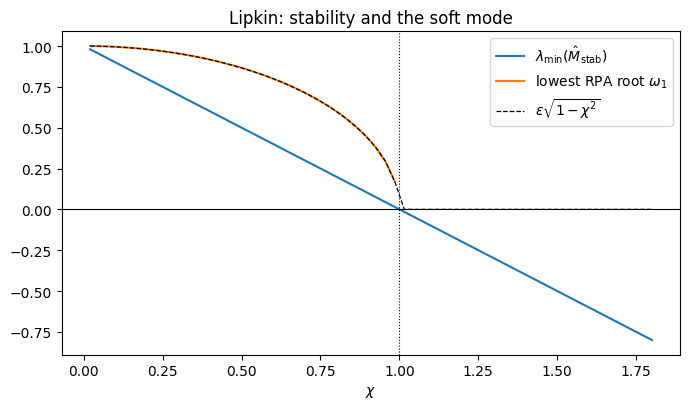

In [10]:
chis = np.linspace(0.02, 1.8, 60)
lowest, omega = [], []
for chi in chis:
    A, B = rpa._lipkin_blocks(N=4, eps=1.0, V=chi / 3.0)
    stab = np.block([[A, B], [B.conj(), A.conj()]])
    lowest.append(np.linalg.eigvalsh(0.5 * (stab + stab.T))[0])
    roots, n_imag = rpa.solve_rpa(A, B)
    omega.append(roots[0] if (len(roots) and n_imag == 0) else np.nan)

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(chis, lowest, label=r"$\lambda_{\min}(\hat M_{\rm stab})$")
ax.plot(chis, omega, label=r"lowest RPA root $\omega_1$")
ax.plot(chis, np.sqrt(np.clip(1 - chis**2, 0, None)), "k--", lw=0.9,
        label=r"$\varepsilon\sqrt{1-\chi^2}$")
ax.axhline(0, color="k", lw=0.8); ax.axvline(1.0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$\chi$"); ax.set_title("Lipkin: stability and the soft mode")
ax.legend(); fig.tight_layout(); plt.show()

## 6. BCS

The pairing mean field is not of Hartree-Fock type: the object that acquires
an expectation value is $\langle P^\dagger_p\rangle$, which does not conserve
particle number.

$$|{\rm BCS}\rangle = \prod_p\left(u_p + v_p\,
  a^\dagger_{p+}a^\dagger_{p-}\right)|0\rangle,\qquad u_p^2+v_p^2=1.$$

Because the trial state is a product over levels the energy is available in
closed form, and it turns out to depend on $g$ and $f$ only through
$g + 2f$: seen from the BCS vacuum the particle-hole term *is* extra pairing.

In [11]:
rpa.demo_bcs()

6. BCS: the pairing mean field
The closed-form energy against the Fock-space expectation value:


   g= 1.6 f= 0.0:  closed form   0.20451907   Fock space   0.20451907   difference 8.9e-16


   g= 1.2 f= 0.1:  closed form   0.51568415   Fock space   0.51568415   difference 0.0e+00


   g= 0.8 f= 0.3:  closed form   0.51568415   Fock space   0.51568415   difference 4.4e-16

Note that the last two rows are identical.  Seen from the BCS
vacuum only the q = r part of the particle-hole term survives, and
it acts as extra pairing: the whole BCS problem depends on g and f
through the single combination g + 2f.
     g      f   g + 2f         E_BCS         gap


  1.40   0.00     1.40    0.51568415    0.789218


...

  0.00   0.70     1.40    0.51568415    0.789218

     g        gap     lambda       <N>   v^2
  0.40    0.00000     1.2500   4.00000   1.000  1.000  0.000  0.000
  0.60    0.00000     1.2500   4.00000   1.000  1.000  0.000  0.000
  0.80    0.00000     1.2500   4.00000   1.000  1.000  0.000  0.000
  1.00    0.00000     1.2500   4.00000   1.000  1.000  0.000  0.000
  1.07    0.00000     1.2207   4.00000   1.000  1.000  0.000  0.000


  1.20    0.46716     1.2000   4.00000   0.984  0.925  0.075  0.016


  1.60    1.05608     1.1000   4.00000   0.934  0.783  0.217  0.066


  2.00    1.54088     1.0000   4.00000   0.887  0.709  0.291  0.113



critical coupling  g_c = 1.07037  (f = 0)
The condition for a non-trivial solution is
   1 = 2S [ 1/(3 xi + S) + 1/(xi + S) ],    S = g/2 + f,
which gives S_c = 0.53519 and hence g_c = 1.07037 at f = 0.

Below g_c the only solution is the normal Fermi sea and BCS
reduces to Hartree-Fock.  Above it a gap opens and the mean field
stops conserving particle number.  In a finite system this sharp
transition is an artefact of the mean field: the exact ground-state
energy of chapter 4 is perfectly smooth through g_c.


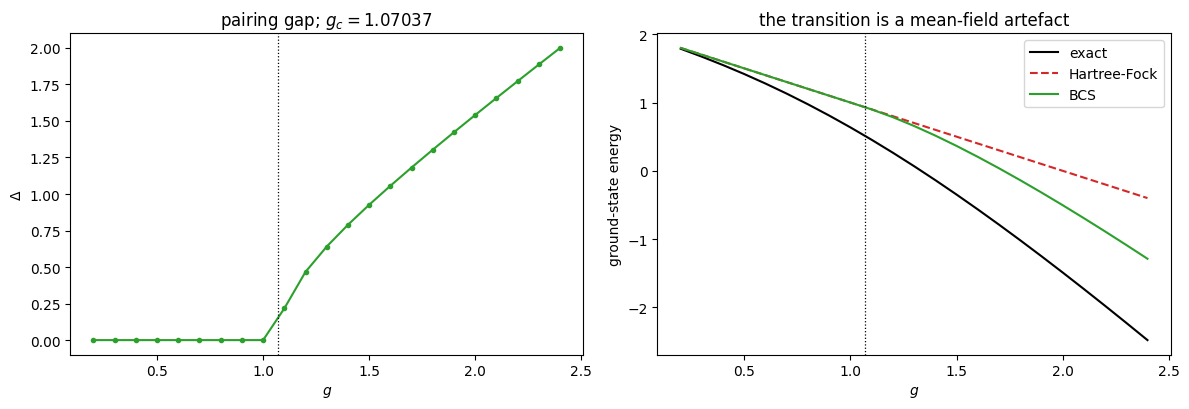

In [12]:
gs = np.linspace(0.2, 2.4, 23)
gap, ebcs, ehf, eex = [], [], [], []
for g in gs:
    b = rpa.BCS(4, 4, g, 0.0); b.solve()
    gap.append(b.gap); ebcs.append(b.E)
    ehf.append(rpa.tda_rpa(fock, 4, g, 0.0)["hf"])
    eex.append(rpa.PairingPH(levels=4, particles=4, g=g, f=0.0).spectrum(1)[0])

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
ax[0].plot(gs, gap, "C2o-", ms=3)
ax[0].axvline(1.07037, color="k", ls=":", lw=0.9)
ax[0].set_xlabel("$g$"); ax[0].set_ylabel(r"$\Delta$")
ax[0].set_title(r"pairing gap; $g_c = 1.07037$")
ax[1].plot(gs, eex, "k-", label="exact")
ax[1].plot(gs, ehf, "C3--", label="Hartree-Fock")
ax[1].plot(gs, ebcs, "C2-", label="BCS")
ax[1].axvline(1.07037, color="k", ls=":", lw=0.9)
ax[1].set_xlabel("$g$"); ax[1].set_ylabel("ground-state energy")
ax[1].set_title("the transition is a mean-field artefact")
ax[1].legend()
fig.tight_layout(); plt.show()

The BCS transition at $g_c = 1.07$ is *sharp* even though the system is
finite -- but the exact curve runs straight through it with no feature at all.
Mean-field phase transitions in finite systems are approximations to smooth
crossovers.

## 7. Quasiparticle RPA

QRPA builds phonons out of pairs of Bogoliubov quasiparticles,

$$\hat Q^\dagger_\nu = \sum_{a<b}\left(X^\nu_{ab}
  \alpha^\dagger_a\alpha^\dagger_b - Y^\nu_{ab}\alpha_b\alpha_a\right),$$

with the same matrix structure.  Two features need care: the **spurious
Goldstone mode** from the broken $U(1)$ symmetry, and the **mode content**,
since quasiparticles mix particle number.

In [13]:
rpa.demo_qrpa()

7. Quasiparticle RPA
max || alpha_a |BCS> ||  = 3.68e-17   (the BCS state is the
                                        quasiparticle vacuum)

The number of two-quasiparticle operators is 2L(2L-1)/2 = 28.
Because BCS breaks particle-number conservation, the QRPA has an
exact zero mode -- the Goldstone mode generated by N.  Numerically
it appears as a tiny root; the table shows its size and its
overlap with the amplitudes built from the number operator.

     g       gap   |w_spurious|   overlap with N   #imaginary


  1.20   0.46716       2.05e-04         1.000000            0


  1.40   0.78922       2.08e-05         1.000000            0


  1.60   1.05608       1.97e-04         1.000000            0


  1.80   1.30338       8.45e-05         1.000000            0


  2.00   1.54088       2.01e-04         1.000000            0

The overlap is one to six decimals: the near-zero root really is
the number mode, and once it is removed the QRPA matrix has no
imaginary eigenvalues at all.  A small imaginary spurious root is
a numerical artefact of the singular metric, not an instability.

The remaining phonons split by the average particle number they
carry.  Modes with <Delta N> = 0 are excitations of the N-particle
system; the others are pairing vibrations reaching towards N +/- 2.



  g = 1.4:  exact excitation energies [2.3565 2.3565 2.676  3.3181]
       omega    <Delta N>   character
      1.3093      -0.0000   Delta N = 0
      1.9084      -0.0000   Delta N = 0
      1.9084      -0.0000   Delta N = 0
      1.9084      -0.0000   Delta N = 0
      1.9084      -0.0000   Delta N = 0
      2.9094      -0.2339   pairing vibration
      2.9094      -0.2339   pairing vibration



  g = 2.0:  exact excitation energies [3.3274 3.3274 3.4897 4.2536]
       omega    <Delta N>   character
      2.6015      -0.0000   Delta N = 0
      2.9212      -0.0000   Delta N = 0
      2.9212      -0.0000   Delta N = 0
      2.9212      -0.0000   Delta N = 0
      2.9212      -0.0000   Delta N = 0
      3.7879       0.3566   pairing vibration
      3.7879       0.3566   pairing vibration


The near-zero root has unit overlap with the amplitudes built from $\hat N$,
identifying it beyond doubt.  A small *imaginary* spurious root is a numerical
artefact of the singular RPA metric, not an instability — this is easy to
mistake, and the overlap test is the way to tell the two apart.  Once the mode
is removed the QRPA matrix has no imaginary eigenvalues anywhere in the
superfluid regime.

## 8. Everything against everything

In [14]:
rpa.demo_comparison()

8. Exact against RPA and QRPA
Pure pairing, f = 0.  E_ref is the unperturbed determinant, which
for this interaction is also the Hartree-Fock energy.
     g     E_exact       E_HF      HF+RPA      E_BCS    BCS+QRPA
  0.40    1.548001    1.60000     1.51748    1.60000     1.46366
  0.60    1.277449    1.40000     1.22390    1.40000     1.08964


  0.80    0.973552    1.20000     0.90179    1.20000     0.62540
  1.00    0.635548    1.00000     0.55459    1.00000    -0.01157


  1.20    0.264504    0.80000     0.18506    0.78522    -0.40860


  1.40   -0.137035    0.60000    -0.20453    0.51568    -0.67091


  1.60   -0.565660    0.40000    -0.61230    0.20452    -1.04351


  2.00   -1.489652    0.00000    -1.47622   -0.50353    -1.94223

Read the table across.  Hartree-Fock does nothing for pure pairing,
so the entire correlation energy must come from the fluctuations.
Particle-hole RPA supplies almost all of it and tracks the exact
curve closely, crossing it between g = 1.6 and g = 2: it is a
little under-bound at weak coupling and a little over-bound at
strong coupling.  BCS improves on Hartree-Fock once the gap opens,
but only modestly, because a mean field that merely smears the
occupations cannot reproduce a genuinely correlated ground state.
QRPA on top of BCS then overshoots badly, and the reason is
visible in section 7 -- the two-quasiparticle space contains
pairing vibrations reaching towards N +/- 2, and the standard
correlation-energy formula counts them all.  Particle-number
projection is needed before BCS + QRPA becomes quantitative for a
system this small.  In a heavy nucleus, where the number of
levels is large and the relative number fluc

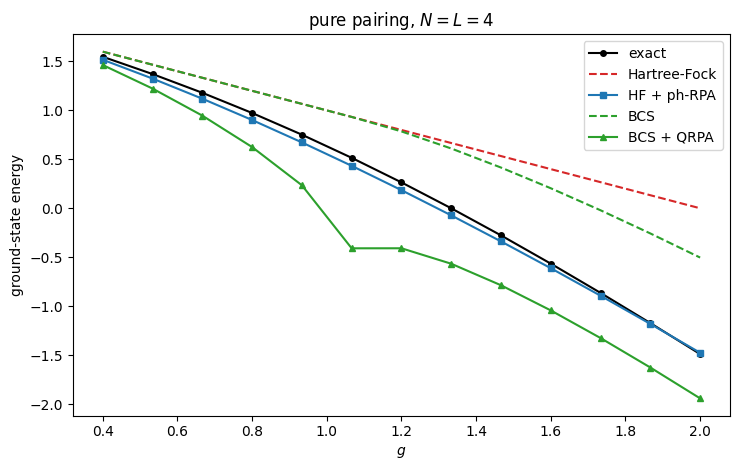

In [15]:
gs = np.linspace(0.4, 2.0, 13)
eex, ehf, erpa, ebcs, eqrpa = [], [], [], [], []
for g in gs:
    eex.append(rpa.PairingPH(levels=4, particles=4, g=g, f=0.0).spectrum(1)[0])
    r = rpa.tda_rpa(fock, 4, g, 0.0)
    ehf.append(r["hf"]); erpa.append(r["hf"] + r["ecorr"])
    q = rpa.qrpa(fock, 4, g, 0.0)
    ebcs.append(q["energy"])
    eqrpa.append(q["energy"] + q["ecorr"] if q["stable"] else np.nan)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.plot(gs, eex, "k-o", ms=4, label="exact")
ax.plot(gs, ehf, "C3--", label="Hartree-Fock")
ax.plot(gs, erpa, "C0-s", ms=4, label="HF + ph-RPA")
ax.plot(gs, ebcs, "C2--", label="BCS")
ax.plot(gs, eqrpa, "C2-^", ms=5, label="BCS + QRPA")
ax.set_xlabel("$g$"); ax.set_ylabel("ground-state energy")
ax.set_title("pure pairing, $N = L = 4$")
ax.legend(); fig.tight_layout(); plt.show()

Particle-hole RPA tracks the exact curve closely and crosses it near
$g\approx1.8$.  BCS improves on Hartree-Fock only above $g_c$, and only
modestly.  QRPA on top of BCS overshoots badly, because the two-quasiparticle
space contains pairing vibrations reaching towards $N\pm2$ and the standard
correlation-energy formula counts every root.  Particle-number projection is
needed before BCS + QRPA becomes quantitative for a system this small; in a
heavy nucleus, where the relative number fluctuation is small, the same
machinery is far better behaved.

## The full program

Everything above lives in `BookManybody/BookMaterial/Programs/rpa.py`, which
runs as a script and prints all eight demonstrations of the chapter.

In [16]:
print(open(rpa.__file__).read())

"""
Tamm-Dancoff, RPA, BCS and QRPA for the pairing plus particle-hole model.

Companion code to chapter 7 of *Quantum mechanics for Many-particle Systems*.

The model has L doubly degenerate, equally spaced levels p = 1, ..., L, each
carrying a spin label sigma = +/-, holding N spin-1/2 fermions:

    H0     = xi sum_{p sigma} (p-1) a^+_{p sigma} a_{p sigma}
    V_pair = -(g/2) sum_{pq}  a^+_{p+} a^+_{p-} a_{q-} a_{q+}
    V_ph   = -(f/2) sum_{pqr} ( a^+_{p+} a^+_{p-} a_{q-} a_{r+} + h.c. )

At f = 0 this is exactly the pairing model of chapter 4, so every number can
be checked against Table 4.2.  The particle-hole term breaks pairs and is
what makes the particle-hole channel non-trivial.

Two references are used and compared:

    HartreeFock  -- the particle-hole mean field; TDA and RPA are built on it
    BCS          -- the pairing mean field; QRPA is built on it

The RPA and QRPA matrices are evaluated as literal ground-state expectation
values of double commutators,

    A_KL = 